In [2]:
import pandas as pd
import seaborn as sns
import pathlib
import matplotlib.pyplot as plt

In [3]:
plot_path = pathlib.Path("../figs")
datapath = pathlib.Path("../data/reports")

In [4]:
df = pd.read_csv(datapath / "offense_vc.csv")
# df["decision"] = df.AppealDecision.replace({"http://growgraph.dev/fcaont#AppealRejected": "AppealRejected"})
# df.loc[df["decision"] != "AppealRejected", "decision"] = "Upheld"
df["Offense Type"] = df.offenseType.apply(lambda x: x.split("#")[-1])
df.head()

,offenseType,count,Offense Type
0,http://growgraph.dev/fcaont#ViolentOffense,537,ViolentOffense
1,http://growgraph.dev/fcaont#PropertyOffense,264,PropertyOffense
2,http://growgraph.dev/fcaont#PublicOrderCrime,262,PublicOrderCrime
3,http://growgraph.dev/fcaont#DrugOffense,239,DrugOffense
4,http://growgraph.dev/fcaont#Fraud,232,Fraud


In [6]:
sorted(df["Offense Type"].unique())

['Assault',
 'Burglary',
 'CyberCrime',
 'Disorderly_Conduct',
 'DrugOffense',
 'Embezzlement',
 'Fraud',
 'Homicide',
 'MoneyLaundering',
 'OffenseType',
 'PropertyOffense',
 'PublicOrderCrime',
 'Robbery',
 'Theft',
 'Vandalism',
 'ViolentOffense',
 'WhiteCollarOffense']

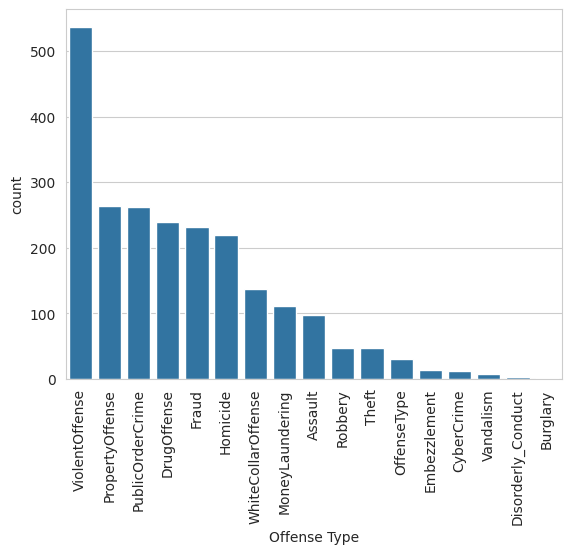

In [17]:
sns.set_style("whitegrid")
ax = sns.barplot(df, x="Offense Type", y="count")
ax.tick_params(axis="x", rotation=90)

plt.savefig(
    plot_path.expanduser() / "offense_type.pdf",
    dpi=300,
    bbox_inches="tight",
)

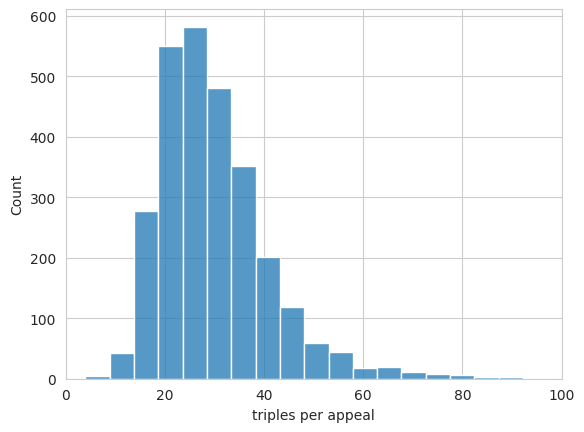

In [18]:
sns.set_style("whitegrid")
df = pd.read_csv(datapath / "triple_count.csv").rename(
    columns={"tripleCount": "triples per appeal"}
)
ax = sns.histplot(df["triples per appeal"], bins=30)
ax.set_xlim([0, 100])
plt.savefig(
    plot_path.expanduser() / "triples.pdf",
    dpi=300,
    bbox_inches="tight",
)

In [19]:
df["triples per appeal"].mean()

np.float64(30.001077586206897)